![logo](img/logoitqv1.jpg)
<br>

# 0.1 Prueba


<br>

![python](img/python_logo.png)

<br>

*Alexis González y Kenin Cusme*

<br>

[link de Git Hub](https://github.com/Mathias255/Machine-E-learning-2-.git)

# Importaciones

In [46]:
#Iportamos las librerias de a utilizar
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
import zipfile
import kagglehub

# 1.Carga y comprensión de los datos — 10 %

In [4]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/mathi/.kaggle"

In [5]:
#Creamos la carpeta dataset
os.makedirs("dataset2", exist_ok=True)

In [9]:
!kaggle datasets download -d mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0




  0%|          | 0.00/16.0k [00:00<?, ?B/s]
100%|##########| 16.0k/16.0k [00:00<00:00, 251kB/s]


In [10]:
with zipfile.ZipFile("insurance.zip", 'r') as zip_ref:
   zip_ref.extractall("dataset2")

In [11]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset2/insurance.csv")
#Leemos las primera filas
print ("Primera filas")
display(df.head())

Primera filas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
#Información general del dataset
print("\nInformación general de dataset2:")
df.info()


Información general de dataset2:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [13]:
#Exploramos las estadisticas descriptiva
print("\nEstadisticas descriptivas del dataset2:")
display(df.describe())


Estadisticas descriptivas del dataset2:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. EDA y calidad de los datos — 15 %

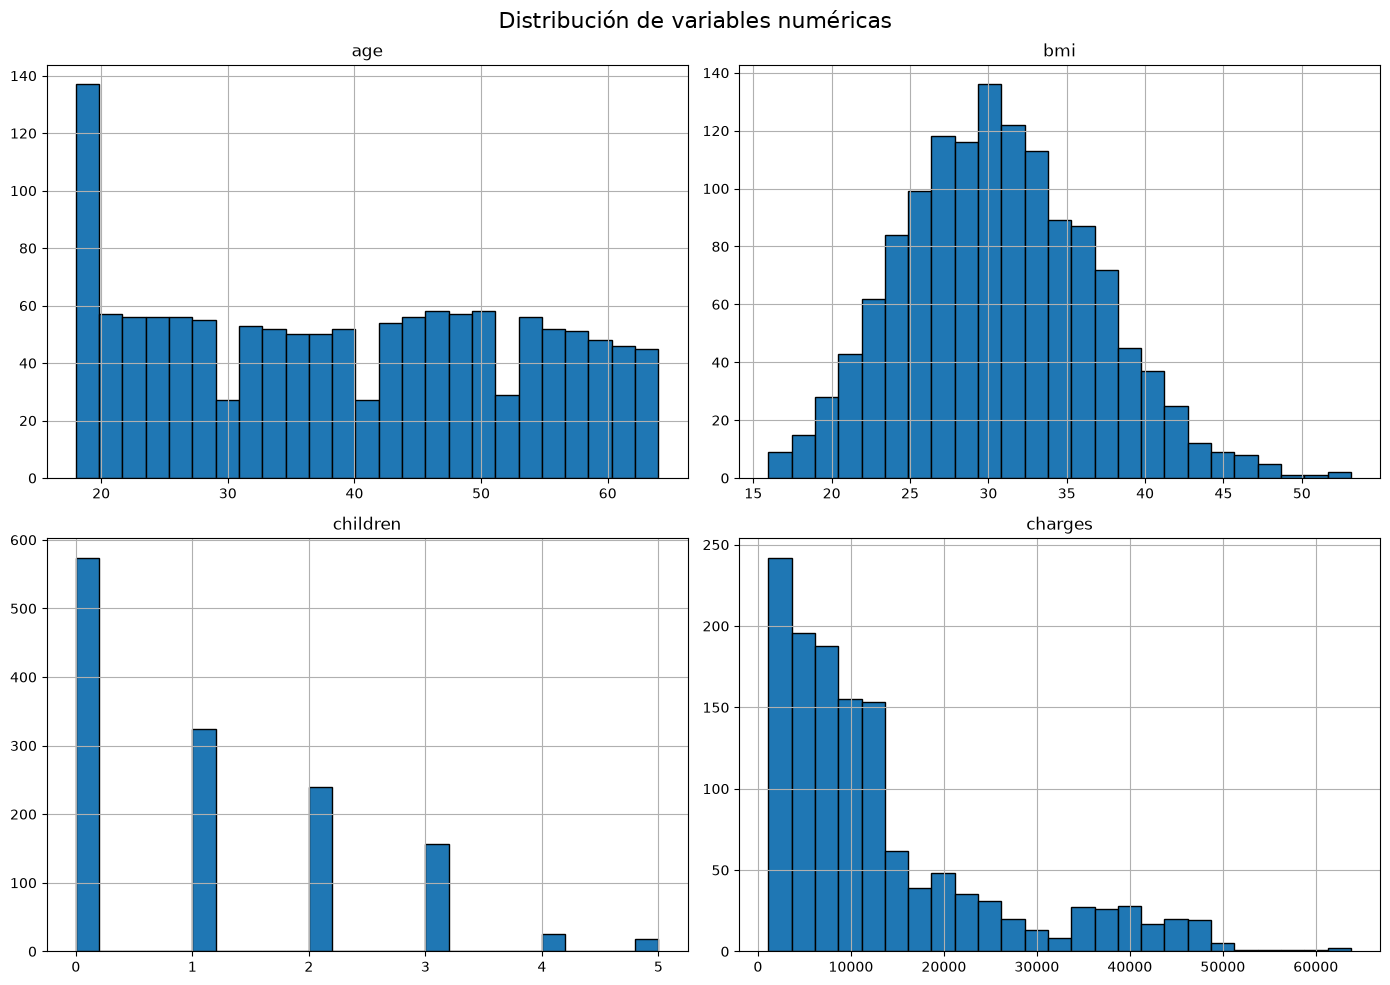

In [14]:
# Distribución de variables numéricas
df.hist(figsize=(14, 10), bins=25, edgecolor="black")
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# Valores faltantes y registros duplicados
print("Valores faltantes por columna:")
display(df.isnull().sum())

print("Número de filas duplicadas:", df.duplicated().sum())

print("\nValores únicos de variables categóricas:")
for col in ["sex", "smoker", "region"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


Valores faltantes por columna:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Número de filas duplicadas: 1

Valores únicos de variables categóricas:

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


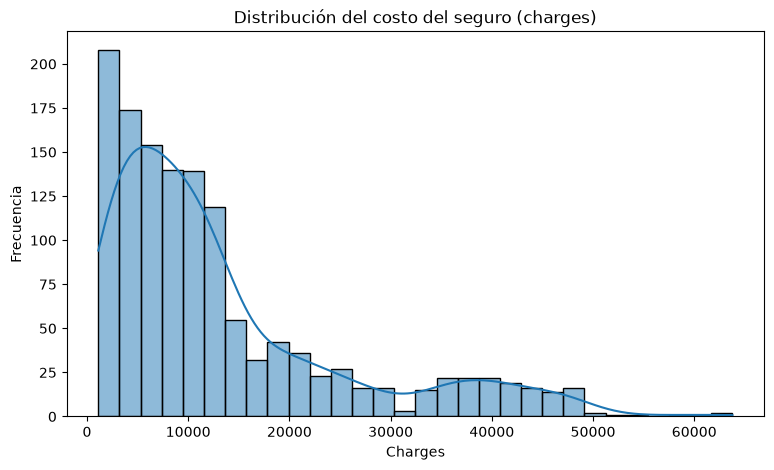

In [16]:
# Distribución de la variable objetivo
plt.figure(figsize=(9, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribución del costo del seguro (charges)")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")
plt.show()

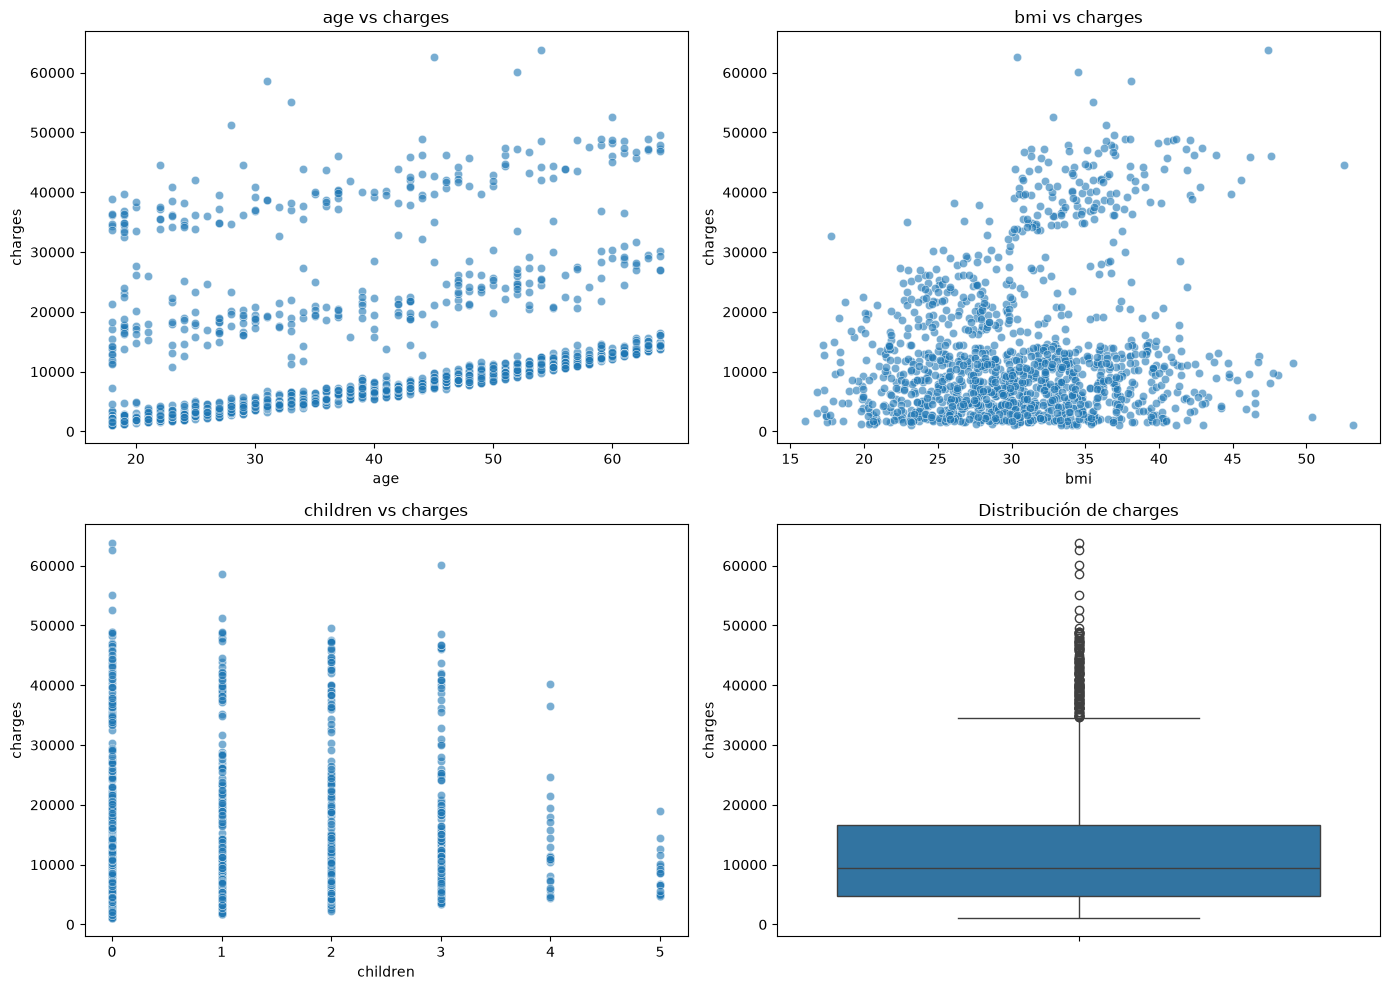

In [17]:
# Relación entre variables numéricas y charges
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.ravel(), ["age", "bmi", "children", "charges"]):
    if col != "charges":
        sns.scatterplot(data=df, x=col, y="charges", ax=ax, alpha=0.6)
        ax.set_title(f"{col} vs charges")
    else:
        sns.boxplot(data=df, y="charges", ax=ax)
        ax.set_title("Distribución de charges")

plt.tight_layout()
plt.show()

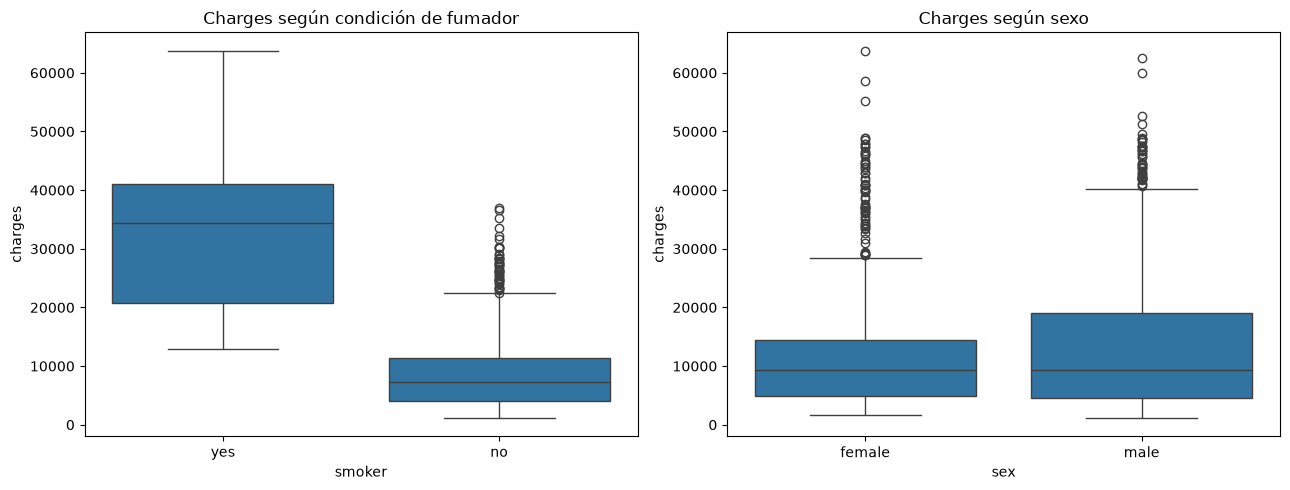

In [18]:
# Comparación de charges según smoker y sex
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])
axes[0].set_title("Charges según condición de fumador")

sns.boxplot(data=df, x="sex", y="charges", ax=axes[1])
axes[1].set_title("Charges según sexo")

plt.tight_layout()
plt.show()


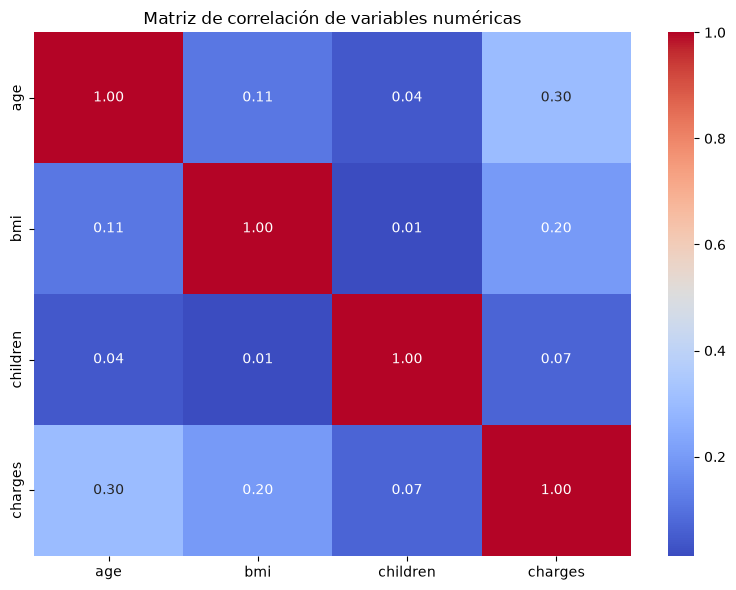

Correlación con charges:


charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

In [19]:
# Correlación de variables numéricas
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

print("Correlación con charges:")
display(corr["charges"].sort_values(ascending=False))


# 3. Detección de outliers — 10 %

In [20]:

# Método IQR para detectar outliers en variables numéricas
numeric_cols = ["age", "bmi", "children", "charges"]

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": lower,
        "limite_superior": upper,
        "cantidad_outliers": int(mask.sum()),
        "porcentaje_outliers": round(mask.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
0,age,27.00000,51.000000,24.000000,-9.000000,87.000000,0,0.00
1,bmi,26.29625,34.693750,8.397500,13.700000,47.290000,9,0.67
2,children,0.00000,2.000000,2.000000,-3.000000,5.000000,0,0.00
3,charges,4740.28715,16639.912515,11899.625365,-13109.150897,34489.350562,139,10.39


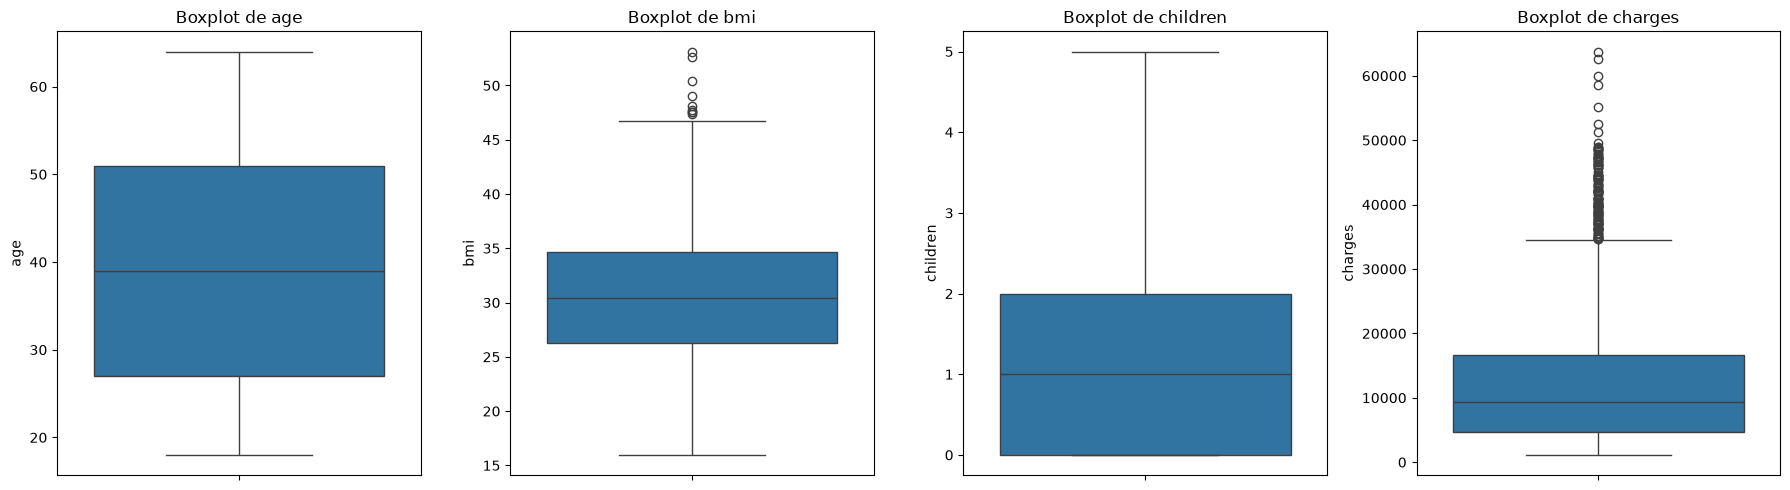

In [21]:
# Visualización de outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()


### Tratamiento de outliers

En este dataset, `charges` presenta valores altos que pueden representar casos reales de costos elevados,
por lo que no se eliminan automáticamente todos los outliers. Se conserva la información y se utiliza
la detección mediante IQR como diagnóstico de calidad.


## 4. Preparación de variables — 10 %

In [22]:
# Eliminar duplicados para evitar repetir observaciones idénticas
df_model = df.drop_duplicates().copy()

print("Filas antes:", len(df))
print("Filas después de eliminar duplicados:", len(df_model))

# Separar variables predictoras (X) y variable objetivo (y)
X = df_model.drop(columns="charges")
y = df_model["charges"]

print("\nVariables predictoras:")
display(X.head())

print("\nVariable objetivo:")
display(y.head())

Filas antes: 1338
Filas después de eliminar duplicados: 1337

Variables predictoras:


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest



Variable objetivo:


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [23]:

# Identificar variables numéricas y categóricas
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: ['age', 'bmi', 'children']
Variables categóricas: ['sex', 'smoker', 'region']


In [26]:
# Codificación de variables categóricas mediante One-Hot Encoding.
# drop="first" evita redundancia perfecta entre categorías.
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## 5. Normalización / estandarización — 10 %

La estandarización de las variables numéricas se realiza dentro del `Pipeline` mediante `StandardScaler`.
Esto permite que el escalado se ajuste únicamente con los datos de entrenamiento y evita fuga de información
(data leakage).

In [29]:
# 1. Separar variables predictoras (X) y variable objetivo (y)

X = df_model.drop(columns="charges")
y = df_model["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

# 2. División en conjuntos de Entrenamiento y Prueba (Train / Test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Definición del Preprocesador (Estandarización + One-Hot Encoding)

# Se aplica StandardScaler a las variables numéricas para dejarlas con media=0 y std=1.
# Se usa drop="first" en OneHotEncoder para evitar la multicolinealidad.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ]
)

# 4. Ajuste y Transformación

# fit_transform() APRENDE la media/std de X_train y transforma X_train
X_train_scaled = preprocessor.fit_transform(X_train)

# transform() USA la media/std aprendidas de X_train para transformar X_test
X_test_scaled = preprocessor.transform(X_test)

print("Preprocesamiento completado con éxito.")
print(f"Dimensiones de X_train transformado: {X_train_scaled.shape}")
print(f"Dimensiones de X_test transformado: {X_test_scaled.shape}")

Preprocesamiento completado con éxito.
Dimensiones de X_train transformado: (1069, 8)
Dimensiones de X_test transformado: (268, 8)


## 6. Selección de atributos — 10 %

In [30]:
# Selección de atributos basada en el problema y en la disponibilidad del dataset.
# Se utilizan como predictores:
# age, bmi, children, sex, smoker y region.
#
# No se utiliza charges como predictor porque es la variable objetivo.
# Tampoco se generan variables a partir de charges para evitar fuga de información.

selected_features = numeric_features + categorical_features

print("Atributos seleccionados:")
for feature in selected_features:
    print("-", feature)

X_selected = X[selected_features].copy()

Atributos seleccionados:
- age
- bmi
- children
- sex
- smoker
- region


## 7. Validación de datos — 10 %

In [32]:
# Definimos la semilla de aleatoriedad
RANDOM_STATE = 42

# Separación en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño entrenamiento: (1069, 6)
Tamaño prueba: (268, 6)
Tamaño y_train: (1069,)
Tamaño y_test: (268,)


In [33]:
# Comprobación de que no hay datos faltantes en los conjuntos
print("Valores faltantes en X_train:")
display(X_train.isnull().sum())

print("Valores faltantes en X_test:")
display(X_test.isnull().sum())

print("Valores faltantes en y_train:", y_train.isnull().sum())
print("Valores faltantes en y_test:", y_test.isnull().sum())

Valores faltantes en X_train:


age         0
bmi         0
children    0
sex         0
smoker      0
region      0
dtype: int64

Valores faltantes en X_test:


age         0
bmi         0
children    0
sex         0
smoker      0
region      0
dtype: int64

Valores faltantes en y_train: 0
Valores faltantes en y_test: 0


In [36]:
# Validación cruzada de 5 particiones.
# El modelo incluye el preprocesamiento dentro del Pipeline.
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rmse = -cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print("RMSE de cada fold:", np.round(cv_rmse, 2))
print("RMSE promedio:", round(cv_rmse.mean(), 2))
print("Desviación estándar RMSE:", round(cv_rmse.std(), 2))

print("\nR² de cada fold:", np.round(cv_r2, 4))
print("R² promedio:", round(cv_r2.mean(), 4))

RMSE de cada fold: [5846.9  6003.92 6130.97 6239.26 6397.21]
RMSE promedio: 6123.65
Desviación estándar RMSE: 189.3

R² de cada fold: [0.729  0.7151 0.7729 0.6884 0.7085]
R² promedio: 0.7228


## 8. Entrenamiento mediante Regresión Lineal — 10 %

In [37]:
# Entrenamiento final con el conjunto de entrenamiento
model.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado correctamente.")

Modelo de Regresión Lineal entrenado correctamente.


In [38]:
# Obtener coeficientes después del One-Hot Encoding
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "atributo": feature_names,
    "coeficiente": coefficients
})

coef_df["abs_coeficiente"] = coef_df["coeficiente"].abs()
coef_df = coef_df.sort_values("abs_coeficiente", ascending=False)

print("Coeficientes del modelo ordenados por magnitud:")
display(coef_df.drop(columns="abs_coeficiente"))

Coeficientes del modelo ordenados por magnitud:


,atributo,coeficiente
4,cat__smoker_yes,23077.764593
0,num__age,3472.975553
1,num__bmi,1927.828251
6,cat__region_southeast,-838.919616
7,cat__region_southwest,-659.139752
2,num__children,636.501185
5,cat__region_northwest,-391.761455
3,cat__sex_male,-101.542054


## 9. Evaluación — 10 %

In [41]:
# Predicciones sobre entrenamiento y prueba
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Métricas
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

resultados = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "RMSE": [rmse_train, rmse_test],
    "MAE": [mae_train, mae_test],
    "R2": [r2_train, r2_test]
})

display(resultados.round(2))

,Conjunto,RMSE,MAE,R2
0,Entrenamiento,6081.11,4181.90,0.73
1,Prueba,5956.34,4177.05,0.81


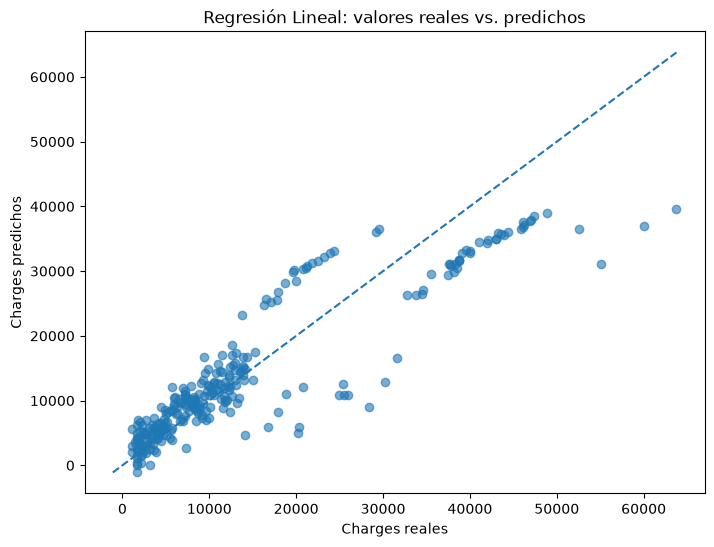

In [42]:
# Valores reales vs. predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], "--")
plt.xlabel("Charges reales")
plt.ylabel("Charges predichos")
plt.title("Regresión Lineal: valores reales vs. predichos")
plt.show()

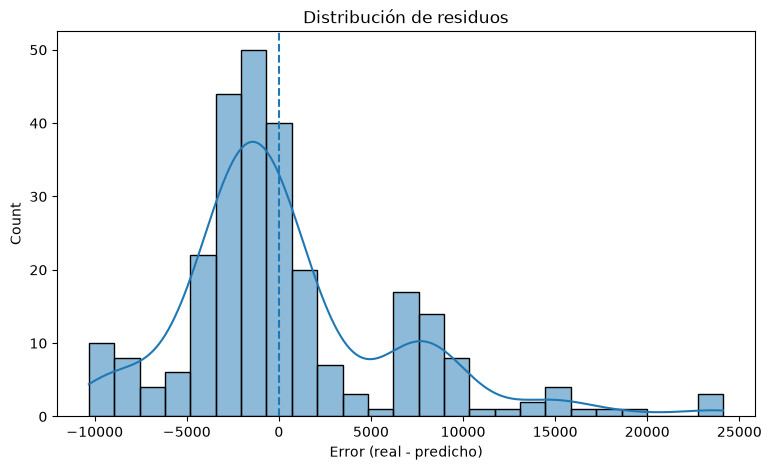

In [43]:
# Distribución de errores
residuos = y_test - y_test_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuos, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Distribución de residuos")
plt.xlabel("Error (real - predicho)")
plt.show()

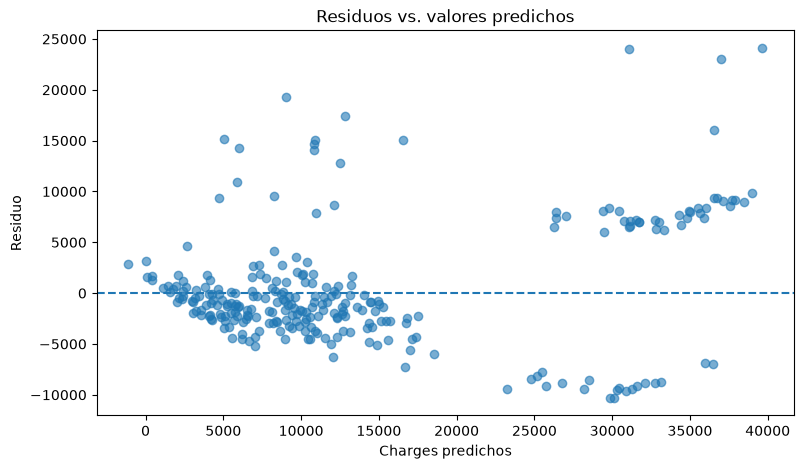

In [44]:
# Residuos frente a valores predichos
plt.figure(figsize=(9, 5))
plt.scatter(y_test_pred, residuos, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Charges predichos")
plt.ylabel("Residuo")
plt.title("Residuos vs. valores predichos")
plt.show()

## 10. Predicción con nuevos datos — 5 %

In [47]:
# Guardar el pipeline completo.
# De esta forma se guardan juntos el preprocesamiento y el modelo.
joblib.dump(model, "modelo_regresion_insurance.pkl")

print("Modelo guardado como: modelo_regresion_insurance.pkl")


Modelo guardado como: modelo_regresion_insurance.pkl


In [48]:
# Cargar el modelo guardado
loaded_model = joblib.load("modelo_regresion_insurance.pkl")

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [49]:
# Función para introducir nuevos datos y obtener una predicción

def predecir_costo_seguro():
    print("=== DATOS DEL NUEVO CLIENTE ===")

    age = int(input("Edad: "))
    sex = input("Sexo (male/female): ").strip().lower()
    bmi = float(input("BMI: "))
    children = int(input("Número de hijos: "))
    smoker = input("¿Fumador? (yes/no): ").strip().lower()
    region = input("Región (northeast/northwest/southeast/southwest): ").strip().lower()

    nuevo = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region
    }])

    prediccion = loaded_model.predict(nuevo)[0]

    print(f"\nCosto estimado del seguro: ${prediccion:,.2f}")
    return prediccion

# Ejecuta esta línea cuando quieras ingresar un nuevo cliente:
# predecir_costo_seguro()


In [50]:
# Ejemplo de predicción con nuevos datos
nuevo_cliente = pd.DataFrame([{
    "age": 35,
    "sex": "male",
    "bmi": 28.5,
    "children": 2,
    "smoker": "no",
    "region": "southeast"
}])

prediccion_ejemplo = loaded_model.predict(nuevo_cliente)[0]

print("Nuevo cliente:")
display(nuevo_cliente)

print(f"Costo estimado del seguro: ${prediccion_ejemplo:,.2f}")

Nuevo cliente:


,age,sex,bmi,children,smoker,region
0,35,male,28.5,2,no,southeast


Costo estimado del seguro: $6,803.27
